Total image: 24


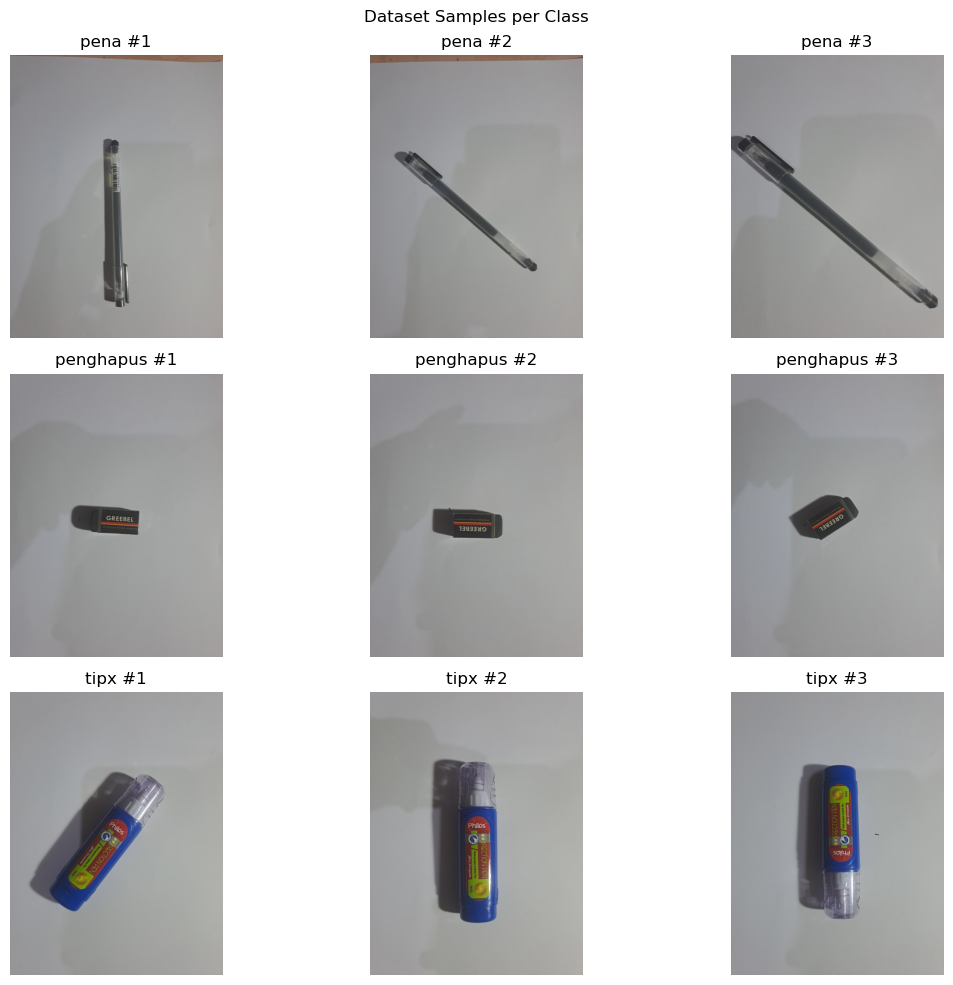

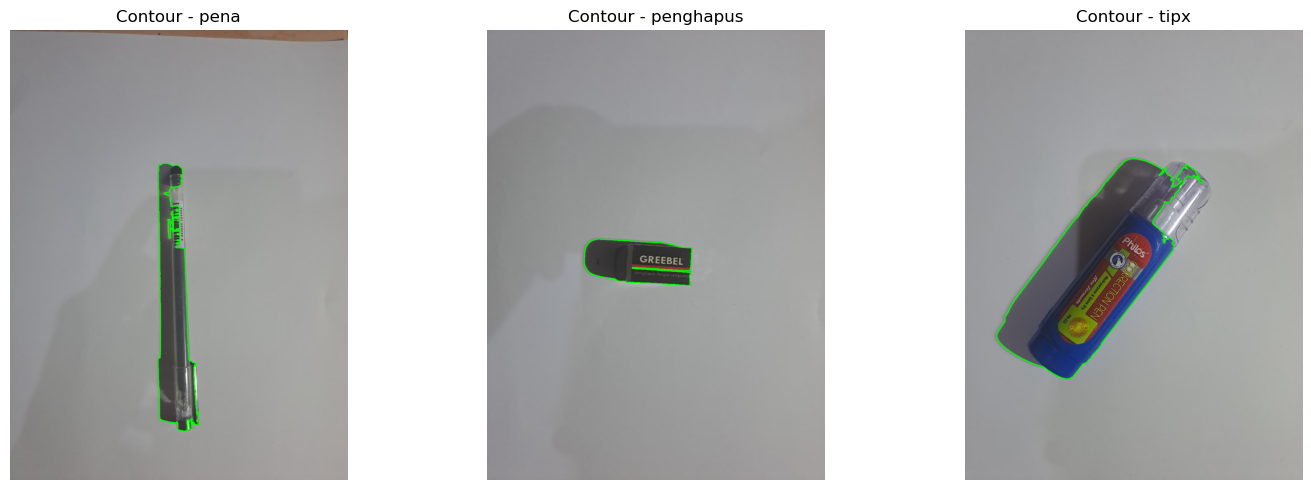

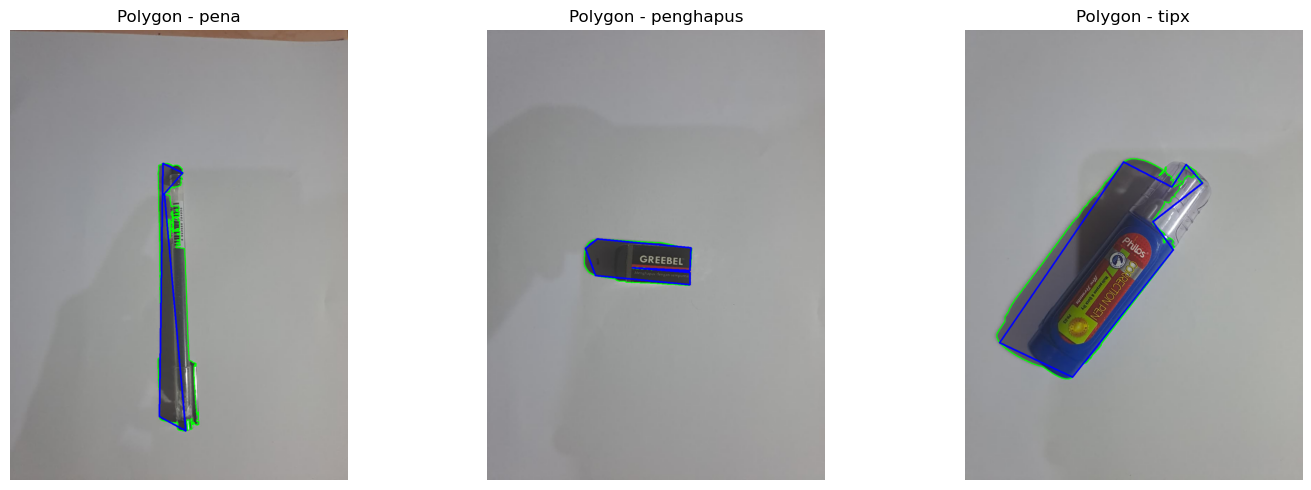

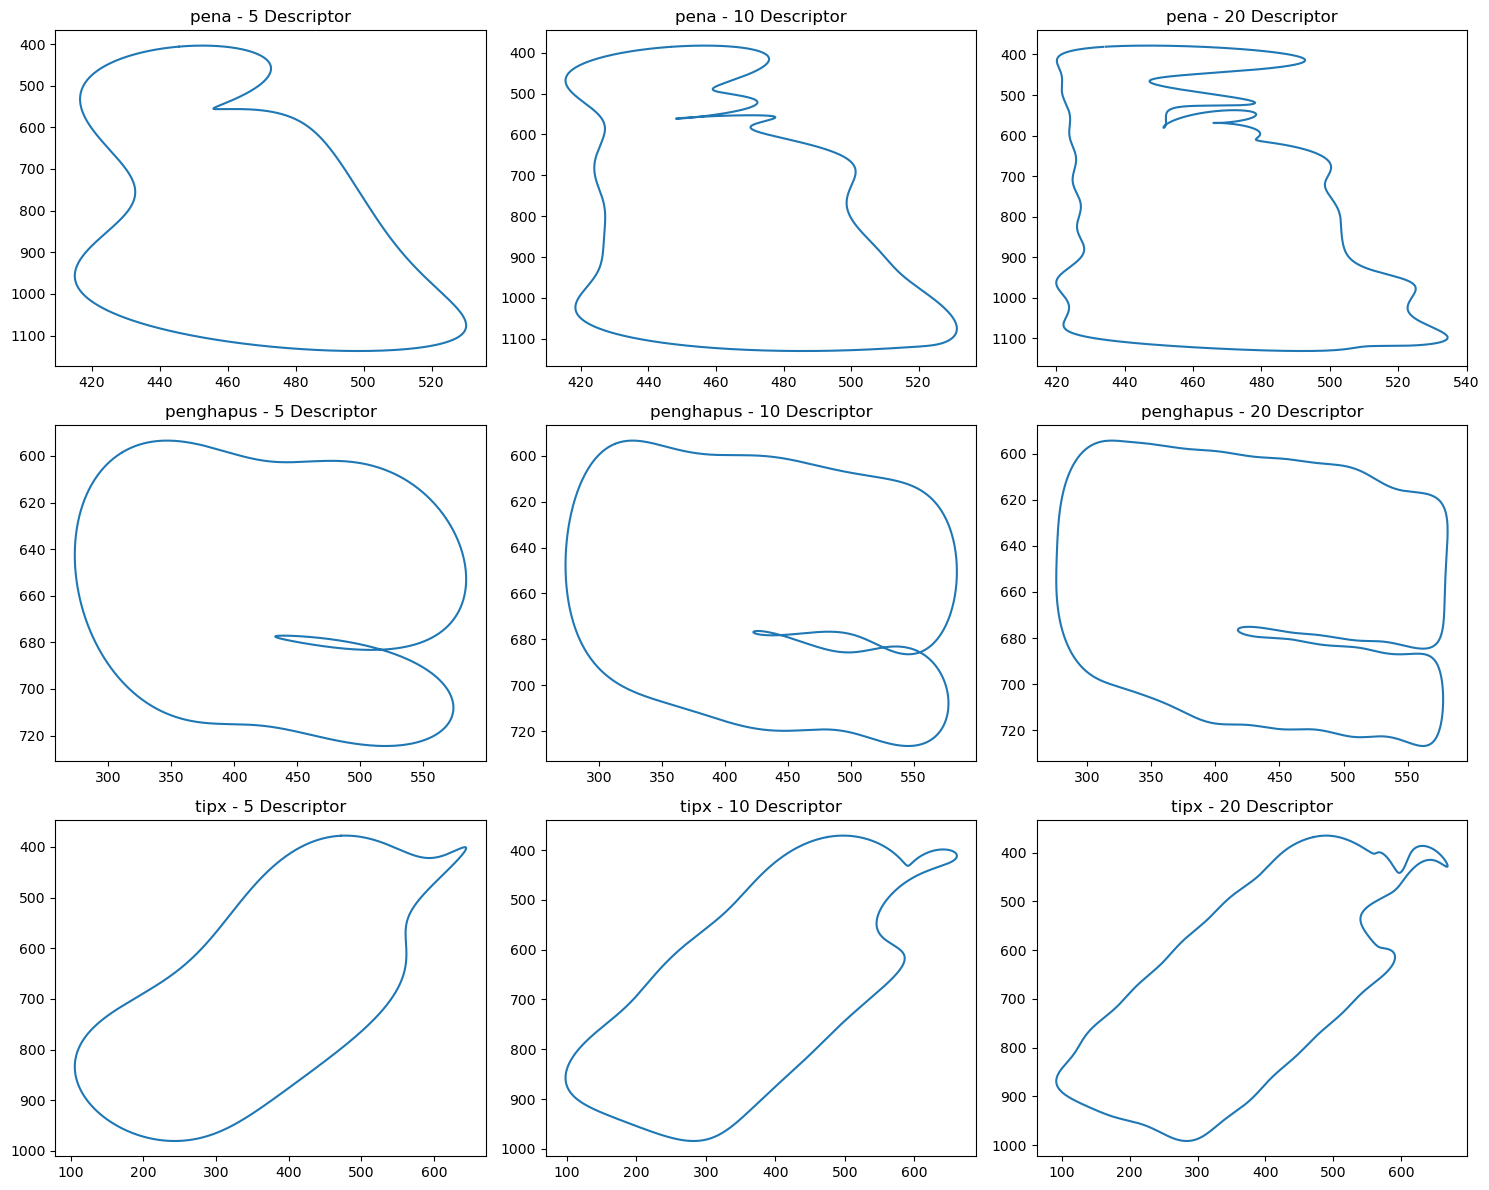

        label      area    perimeter  aspect_ratio    extent  solidity  \
0        pena   54794.0  2396.121926      0.153543  0.614599  0.786011   
1        pena   39676.5  1994.161803      1.181985  0.113429  0.729736   
2        pena   81475.0  2908.599526      1.188776  0.111504  0.711640   
3        pena   65698.5  2301.109733      0.136782  0.634584  0.750176   
4        pena   74864.0  4647.622364      0.750000  0.060924  0.110907   
5        pena   54407.5  2098.657189      1.475104  0.158760  0.756648   
6        pena   33697.0  1974.499562     11.577465  0.577379  0.713859   
7        pena   44177.0  2093.612260      9.917647  0.616524  0.751623   
8   penghapus   32512.0  1145.989895      2.300752  0.798860  0.962079   
9   penghapus   36494.0   881.220343      2.299270  0.845649  0.972473   
10  penghapus   39857.0   837.803165      1.536946  0.629295  0.986926   
11  penghapus   43115.0   840.048770      0.841667  0.889336  0.979208   
12  penghapus   38192.0  1135.640821  

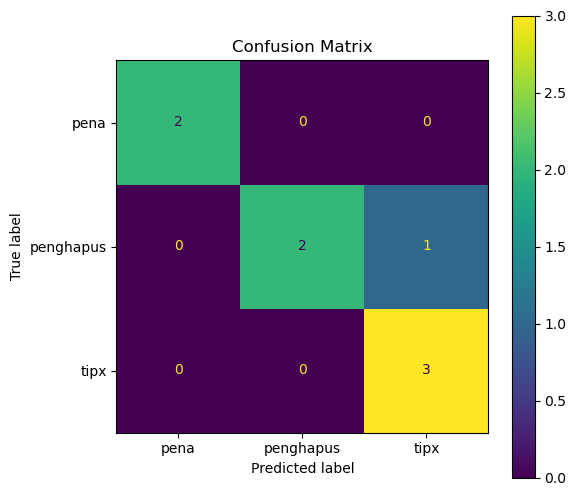

Feature set terbaik:
Feature Set    Combined
Accuracy          0.875
Name: 3, dtype: object


In [9]:
# 1. Import Library
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# 2. Load Dataset
DATASET_PATH = 'dataset'
classes = ['pena', 'penghapus', 'tipx']

images = []
labels = []
paths = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        image = cv2.imread(img_path)

        if image is not None:
            images.append(image)
            labels.append(cls)
            paths.append(img_path)

print(f'Total image: {len(images)}')

# 3. Visualisasi Dataset
samples_per_class = 3

fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(12,10))

for row, cls in enumerate(classes):

    class_images = [
        img for img, lbl in zip(images, labels)
        if lbl == cls
    ]

    for col in range(samples_per_class):

        image = class_images[col]

        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(rgb)
        axes[row, col].set_title(f'{cls} #{col+1}')
        axes[row, col].axis('off')

plt.suptitle('Dataset Samples per Class')
plt.tight_layout()
plt.show()

# 4. Preprocessing
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, thresh = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    kernel = np.ones((3,3), np.uint8)

    clean = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel
    )

    return gray, clean
    
# 5. Contour Extraction
def extract_contour(binary):
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        return None

    largest = max(contours, key=cv2.contourArea)

    return largest

# 6. Visualisasi Contour Semua Kelas
fig, axes = plt.subplots(1, len(classes), figsize=(15,5))

for ax, cls in zip(axes, classes):

    idx = labels.index(cls)

    sample = images[idx]

    gray, binary = preprocess_image(sample)

    contour = extract_contour(binary)

    canvas = sample.copy()

    cv2.drawContours(canvas, [contour], -1, (0,255,0), 2)

    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Contour - {cls}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# 7. Ekstraksi Properti Region
def extract_region_features(contour):
    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(contour, True)

    moments = cv2.moments(contour)

    if moments['m00'] != 0:
        cx = int(moments['m10'] / moments['m00'])
        cy = int(moments['m01'] / moments['m00'])
    else:
        cx, cy = 0, 0

    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = float(w) / h

    rect_area = w * h

    extent = float(area) / rect_area

    hull = cv2.convexHull(contour)

    hull_area = cv2.contourArea(hull)

    solidity = float(area) / hull_area

    return {
        'area': area,
        'perimeter': perimeter,
        'centroid_x': cx,
        'centroid_y': cy,
        'aspect_ratio': aspect_ratio,
        'extent': extent,
        'solidity': solidity
    }

# 8. Ekstraksi Moments
def extract_moment_features(contour):
    m = cv2.moments(contour)

    hu = cv2.HuMoments(m).flatten()

    return {
        'm00': m['m00'],
        'm10': m['m10'],
        'm01': m['m01'],
        'mu20': m['mu20'],
        'mu02': m['mu02'],
        'mu11': m['mu11'],
        'hu1': hu[0],
        'hu2': hu[1],
        'hu3': hu[2],
        'hu4': hu[3],
        'hu5': hu[4],
        'hu6': hu[5],
        'hu7': hu[6]
    }
    
# 9. Chain Code
def chain_code_8(contour):
    directions = {
        (1,0): 0,
        (1,-1): 1,
        (0,-1): 2,
        (-1,-1): 3,
        (-1,0): 4,
        (-1,1): 5,
        (0,1): 6,
        (1,1): 7
    }

    pts = contour.squeeze()

    code = []

    for i in range(len(pts)-1):
        dx = np.sign(pts[i+1][0] - pts[i][0])
        dy = np.sign(pts[i+1][1] - pts[i][1])

        if (dx, dy) in directions:
            code.append(directions[(dx,dy)])

    return code

# 10. Normalisasi Chain Code
def normalize_chain_code(code):
    norm = []

    for i in range(len(code)-1):
        diff = (code[i+1] - code[i]) % 8
        norm.append(diff)

    return norm
    
# 11. Polygonal Approximation
def polygon_approximation(contour):
    epsilon = 0.02 * cv2.arcLength(contour, True)

    approx = cv2.approxPolyDP(contour, epsilon, True)

    return approx
    
# 12. Visualisasi Polygon Approximation Semua Kelas
fig, axes = plt.subplots(1, len(classes), figsize=(15,5))

for ax, cls in zip(axes, classes):

    idx = labels.index(cls)

    sample = images[idx]

    _, binary = preprocess_image(sample)

    contour = extract_contour(binary)

    approx = polygon_approximation(contour)

    canvas = sample.copy()

    cv2.drawContours(canvas, [contour], -1, (0,255,0), 2)
    cv2.drawContours(canvas, [approx], -1, (255,0,0), 3)

    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Polygon - {cls}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# 13. Fourier Descriptor
def fourier_descriptor(contour, n=20):
    contour_array = contour.squeeze()

    complex_contour = np.empty(contour_array.shape[0], dtype=complex)

    complex_contour.real = contour_array[:,0]
    complex_contour.imag = contour_array[:,1]

    fft_result = np.fft.fft(complex_contour)

    descriptors = np.abs(fft_result)

    descriptors = descriptors[:n]

    descriptors = descriptors / descriptors[1]

    return descriptors, fft_result

# 14. Rekonstruksi Fourier
def reconstruct_contour(fft_result, keep):
    fft_copy = np.copy(fft_result)

    fft_copy[keep:-keep] = 0

    recon = np.fft.ifft(fft_copy)

    return recon
    
# 15. Visualisasi Fourier Reconstruction Semua Kelas
fig, axes = plt.subplots(len(classes), 3, figsize=(15,12))

for row, cls in enumerate(classes):

    idx = labels.index(cls)

    sample = images[idx]

    _, binary = preprocess_image(sample)

    contour = extract_contour(binary)

    fd, fft_result = fourier_descriptor(contour, 20)

    recon5 = reconstruct_contour(fft_result, 5)
    recon10 = reconstruct_contour(fft_result, 10)
    recon20 = reconstruct_contour(fft_result, 20)

    reconstructions = [
        (recon5, '5 Descriptor'),
        (recon10, '10 Descriptor'),
        (recon20, '20 Descriptor')
    ]

    for col, (recon, title) in enumerate(reconstructions):

        axes[row, col].plot(recon.real, recon.imag)
        axes[row, col].invert_yaxis()
        axes[row, col].set_title(f'{cls} - {title}')

plt.tight_layout()
plt.show()

# 16. Ekstraksi Semua Fitur
feature_rows = []

for image, label, path in zip(images, labels, paths):

    gray, binary = preprocess_image(image)

    contour = extract_contour(binary)

    if contour is None:
        continue

    region = extract_region_features(contour)

    moments = extract_moment_features(contour)

    chain = chain_code_8(contour)

    normalized_chain = normalize_chain_code(chain)

    fd, _ = fourier_descriptor(contour, 20)

    row = {}

    row.update(region)
    row.update(moments)

    for i in range(5):
        row[f'fd_{i}'] = fd[i]

    row['label'] = label

    feature_rows.append(row)

# 17. DataFrame Fitur
features_df = pd.DataFrame(feature_rows)

features_df.head()

# 18. Tabel Properti Region dan Moments
columns = [
    'label',
    'area',
    'perimeter',
    'aspect_ratio',
    'extent',
    'solidity',
    'm00',
    'mu20',
    'mu02',
    'hu1',
    'hu2',
    'hu3'
]

region_moment_table = features_df[columns]

print(region_moment_table)


# 19. Rata-rata Properti per Kelas
summary_table = features_df.groupby('label')[[
    'area',
    'perimeter',
    'aspect_ratio',
    'extent',
    'solidity',
    'hu1',
    'hu2',
    'hu3'
]].mean()

print(summary_table)

# 20. Chain Code Output Semua Kelas
for cls in classes:

    idx = labels.index(cls)

    sample = images[idx]

    _, binary = preprocess_image(sample)

    contour = extract_contour(binary)

    chain = chain_code_8(contour)

    normalized = normalize_chain_code(chain)

    print('=' * 60)
    print(f'CLASS: {cls}')

    print('Raw Chain Code:')
    print(chain[:50])

    print('Normalized Chain Code:')
    print(normalized[:50])

    print(' ')

# 20. Feature Selection
selected_features = [
    'aspect_ratio',
    'solidity',
    'hu1',
    'hu2',
    'fd_1',
    'fd_2'
]

X = features_df[selected_features]
y = features_df['label']

# 21. Normalisasi Feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 22. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 23. KNN Classification
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# 24. Accuracy
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy: {acc * 100:.2f}%')

# 25. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
).plot(ax=ax)

plt.title('Confusion Matrix')
plt.show()

# 26. Evaluasi Kombinasi Fitur
feature_sets = {
    'Region': ['aspect_ratio', 'extent', 'solidity'],

    'Moments': ['hu1', 'hu2', 'hu3'],

    'Fourier': ['fd_1', 'fd_2', 'fd_3'],

    'Combined': [
        'aspect_ratio',
        'solidity',
        'hu1',
        'hu2',
        'fd_1',
        'fd_2'
    ]
}

results = []

for name, cols in feature_sets.items():

    X = features_df[cols]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    model = KNeighborsClassifier(n_neighbors=3)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append([name, acc])

results_df = pd.DataFrame(results, columns=['Feature Set', 'Accuracy'])

results_df

# 27. Identifikasi Fitur Paling Diskriminatif
best = results_df.sort_values(by='Accuracy', ascending=False)

best

# 28. Kesimpulan
print('Feature set terbaik:')
print(best.iloc[0])
